# Customer Churn Prediction with KNN

**Part 2: Unguided Exercise — sklearn Model Training + Evaluation**  
**Author:** Sergii Rostovskyi

### Objective
Build and evaluate a K-Nearest Neighbors (KNN) classifier that predicts whether a telecommunications customer will churn. The workflow follows the lab requirements: load and explore the data, preprocess it, split it into training/testing sets, train KNN, evaluate it, compare several values of `k`, and translate the findings into business recommendations.

> **Dataset note:** the supplied file has an `.xls` extension, but its contents are comma-separated text. Therefore it is intentionally loaded with `pandas.read_csv()`.

## 1. Load and Explore the Data

I first load the dataset and inspect its dimensions, columns, data types, missing values, and target distribution. I also check `TotalCharges` separately because text-formatted numeric columns can contain blank strings that `isna()` does not initially detect.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# The supplied file is CSV-formatted despite the .xls extension.
candidate_paths = [
    Path("WA_Fn-UseC_-Telco-Customer-Churn.xls"),
    Path("WA_Fn-UseC_-Telco-Customer-Churn.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Put WA_Fn-UseC_-Telco-Customer-Churn.xls "
        "(or .csv) in the same folder as this notebook."
    )

df = pd.read_csv(data_path)
print(f"Loaded: {data_path}")
print(f"Dataset shape: {df.shape}")
df.head()

Loaded: WA_Fn-UseC_-Telco-Customer-Churn.xls
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values detected before conversion:")
print(df.isna().sum()[df.isna().sum() > 0])

blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()
print(f"\nBlank strings in TotalCharges: {blank_total_charges}")

print("\nTarget distribution:")
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True).mul(100)
print(pd.DataFrame({"count": churn_counts, "percent": churn_pct}))

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values detected before conversion:
Series([

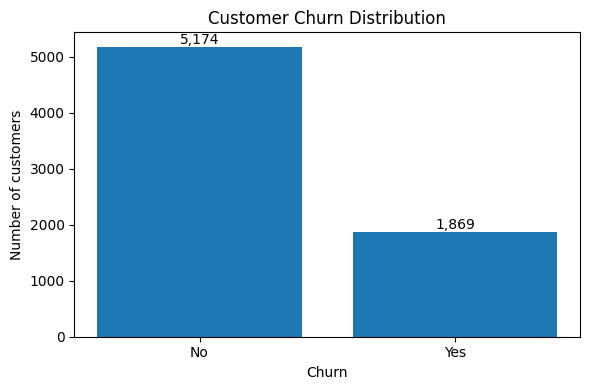

In [3]:
# Target distribution visualization
churn_order = ["No", "Yes"]
counts = df["Churn"].value_counts().reindex(churn_order)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of customers")
for i, value in enumerate(counts.values):
    plt.text(i, value + 50, f"{value:,}", ha="center")
plt.tight_layout()
plt.savefig("data_exploration_and_preprocessing.png", dpi=150, bbox_inches="tight")
plt.show()

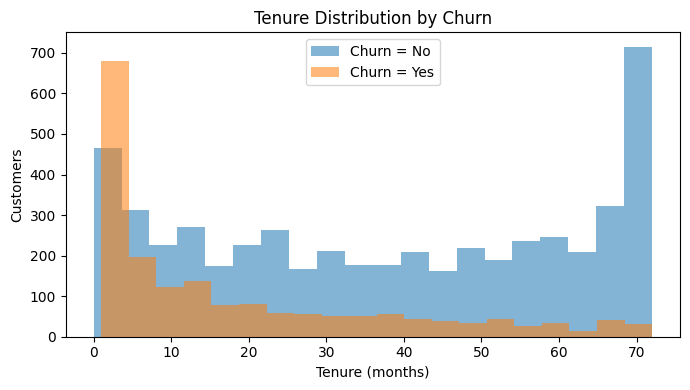

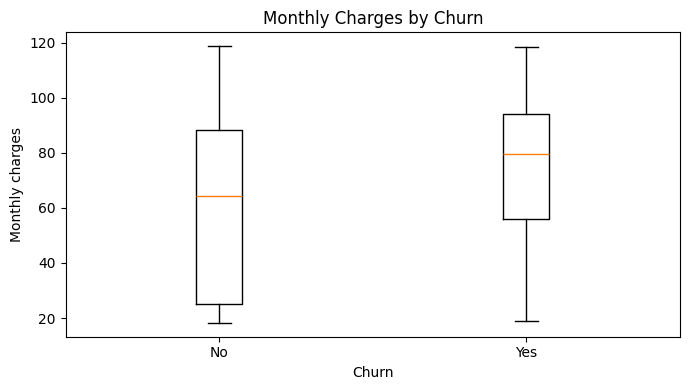

In [4]:
# Two numeric features that are easy to interpret in relation to churn.
plt.figure(figsize=(7, 4))
for churn_value in ["No", "Yes"]:
    plt.hist(
        df.loc[df["Churn"] == churn_value, "tenure"],
        bins=20,
        alpha=0.55,
        label=f"Churn = {churn_value}",
    )
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Customers")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
monthly_no = df.loc[df["Churn"] == "No", "MonthlyCharges"]
monthly_yes = df.loc[df["Churn"] == "Yes", "MonthlyCharges"]
plt.boxplot([monthly_no, monthly_yes], tick_labels=["No", "Yes"])
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly charges")
plt.tight_layout()
plt.show()

### Exploration observations

The target is imbalanced: most customers did **not** churn. This means accuracy alone can be misleading, so precision and especially recall for the churn class must also be evaluated. The distributions also suggest that tenure and monthly charges may be associated with churn.

## 2. Data Preprocessing

Preprocessing decisions:

- Convert `TotalCharges` from text to numeric. Blank strings become missing values.
- Drop `customerID` because it is an identifier rather than a meaningful predictive feature.
- Map `Churn` from `Yes/No` to `1/0`.
- Split the raw predictors into training and test sets **before fitting preprocessing steps**.
- Use a reusable `ColumnTransformer` / `Pipeline`: numeric columns are median-imputed and standardized, while categorical columns are one-hot encoded with `handle_unknown="ignore"`.
- Keeping preprocessing inside the pipeline means the imputer, scaler, and encoder are fitted only on the training data (and only on each training fold during cross-validation), which avoids data leakage and makes the workflow easier to reuse.

KNN is distance-based, so scaling the numeric features is important; otherwise variables with large numeric ranges can dominate the distance calculation.

In [5]:
model_df = df.copy()

# Convert TotalCharges to numeric. Blank strings become NaN.
model_df["TotalCharges"] = pd.to_numeric(model_df["TotalCharges"], errors="coerce")
missing_total_charges = model_df["TotalCharges"].isna().sum()

# Remove identifier and convert target to binary.
model_df = model_df.drop(columns=["customerID"])
model_df["Churn"] = model_df["Churn"].map({"No": 0, "Yes": 1})

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

# Columns handled by the two branches of the preprocessing pipeline.
numeric_columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
categorical_columns = [c for c in X.columns if c not in numeric_columns]

print(f"Missing TotalCharges values before pipeline imputation: {missing_total_charges}")
print(f"Numeric columns ({len(numeric_columns)}): {numeric_columns}")
print(f"Categorical columns ({len(categorical_columns)}): {categorical_columns}")
print(f"Target values: {sorted(y.unique())}")
X.head()

Missing TotalCharges values before pipeline imputation: 11
Numeric columns (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target values: [np.int64(0), np.int64(1)]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650


## 3. Split the Data

The lab specifies an 80/20 split, `random_state=42`, and stratification so the churn ratio remains similar in the training and test sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Training churn rate: {y_train.mean():.3%}")
print(f"Test churn rate:     {y_test.mean():.3%}")

# Numeric features: median imputation + standardization.
# Categorical features: one-hot encoding; unseen categories are safely ignored.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
    ]
)

print("\nReusable preprocessing pipeline created successfully.")

Training set: 5,634 rows
Test set:     1,409 rows
Training churn rate: 26.535%
Test churn rate:     26.544%

Reusable preprocessing pipeline created successfully.


## 4. Train the Initial KNN Model (`k = 5`)

The initial model keeps preprocessing and KNN in one pipeline. This is useful for KNN because every training or prediction step receives data processed in exactly the same way.

In [7]:
knn_5 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
])

knn_5.fit(X_train, y_train)
pred_5 = knn_5.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, pred_5):.3f}")
print(f"Precision: {precision_score(y_test, pred_5):.3f}")
print(f"Recall:    {recall_score(y_test, pred_5):.3f}")
print(f"F1 score:  {f1_score(y_test, pred_5):.3f}")

Accuracy:  0.764
Precision: 0.553
Recall:    0.575
F1 score:  0.564


## 5. Make Predictions and Evaluate

The confusion matrix is organized as:

`[[true negatives, false positives], [false negatives, true positives]]`

For churn, false negatives are especially important because they are customers who actually churn but were predicted as non-churners.

In [8]:
cm_5 = confusion_matrix(y_test, pred_5)
print("Confusion matrix for k=5:")
print(cm_5)
print("\nClassification report for k=5:")
print(classification_report(y_test, pred_5, target_names=["No Churn", "Churn"]))

Confusion matrix for k=5:
[[861 174]
 [159 215]]

Classification report for k=5:
              precision    recall  f1-score   support

    No Churn       0.84      0.83      0.84      1035
       Churn       0.55      0.57      0.56       374

    accuracy                           0.76      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.76      0.77      1409



## 6. Experiment with Different K Values

The required values are `1, 3, 5, 7, 9, 11, 15`.

Instead of choosing `k` from the test set, I use **5-fold stratified cross-validation on the training set**. This keeps the test set untouched until the final evaluation and gives a more robust estimate than a single split.

I compare accuracy, precision, recall, and F1. **F1 is the selection metric** because churn is imbalanced and F1 balances precision (avoiding unnecessary retention actions) with recall (finding actual churners).

In [9]:
k_values = [1, 3, 5, 7, 9, 11, 15]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for k in k_values:
    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
        },
    )

    results.append({
        "k": k,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
    })

results_df = pd.DataFrame(results).set_index("k")

print("Cross-validation results sorted by mean F1 score:")
display(results_df.sort_values("f1", ascending=False))

Cross-validation results sorted by mean F1 score:


,accuracy,precision,recall,f1,f1_std
k,,,,,
15,0.782,0.595,0.562,0.578,0.016
11,0.779,0.587,0.565,0.575,0.011
9,0.778,0.586,0.559,0.572,0.006
7,0.776,0.583,0.551,0.566,0.015
5,0.765,0.561,0.536,0.548,0.016
3,0.750,0.530,0.511,0.520,0.019
1,0.714,0.463,0.493,0.477,0.027


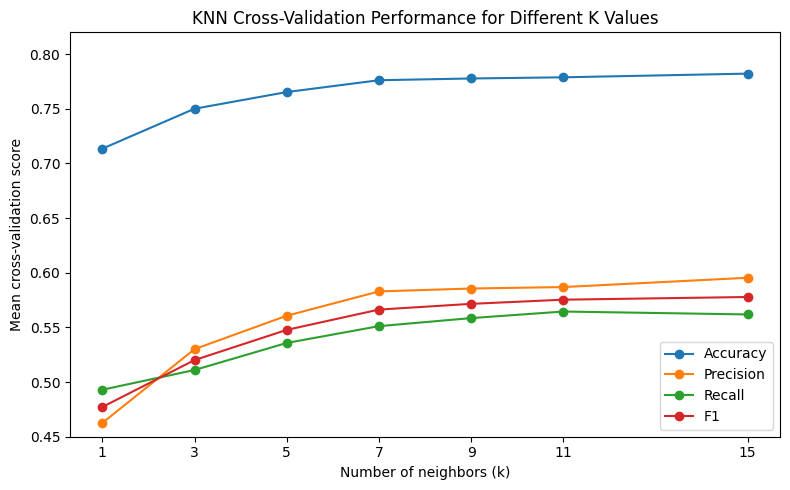

Best k by mean cross-validation F1 score: 15
accuracy    0.782
precision   0.595
recall      0.562
f1          0.578
f1_std      0.016
Name: 15, dtype: float64


In [10]:
plt.figure(figsize=(8, 5))
for metric in ["accuracy", "precision", "recall", "f1"]:
    plt.plot(results_df.index, results_df[metric], marker="o", label=metric.capitalize())
plt.title("KNN Cross-Validation Performance for Different K Values")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Mean cross-validation score")
plt.xticks(k_values)
plt.ylim(0.45, 0.82)
plt.legend()
plt.tight_layout()
plt.savefig("comparison_of_different_k_values.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = int(results_df["f1"].idxmax())
print(f"Best k by mean cross-validation F1 score: {best_k}")
print(results_df.loc[best_k])

In [11]:
# Fit the selected model on the full training set, then evaluate ONCE on the held-out test set.
best_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=best_k)),
])

best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)
best_cm = confusion_matrix(y_test, best_pred)

print(f"Selected model from cross-validation: KNN with k={best_k}")
print(f"Accuracy:  {accuracy_score(y_test, best_pred):.3f}")
print(f"Precision: {precision_score(y_test, best_pred):.3f}")
print(f"Recall:    {recall_score(y_test, best_pred):.3f}")
print(f"F1 score:  {f1_score(y_test, best_pred):.3f}")
print("\nClassification report:")
print(classification_report(y_test, best_pred, target_names=["No Churn", "Churn"]))

print("Confusion matrix:")
print(best_cm)

Selected model from cross-validation: KNN with k=15
Accuracy:  0.777
Precision: 0.583
Recall:    0.564
F1 score:  0.573

Classification report:
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.85      1035
       Churn       0.58      0.56      0.57       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.78      0.78      1409

Confusion matrix:
[[884 151]
 [163 211]]


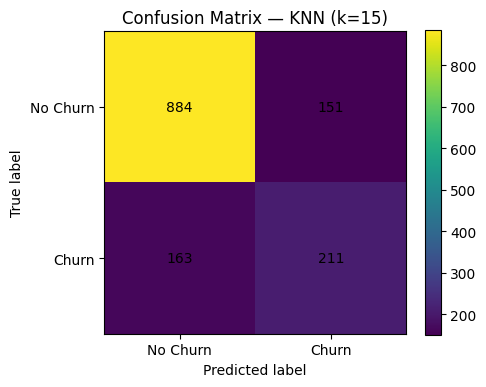

In [12]:
# Visualize confusion matrix without external plotting libraries.
plt.figure(figsize=(5, 4))
plt.imshow(best_cm)
plt.title(f"Confusion Matrix — KNN (k={best_k})")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, best_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig("model_training_and_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Analysis of Churn Patterns and Business Recommendations

KNN does not provide built-in feature importance scores. Instead of claiming causal importance, I explore **associations** between individual features and churn through churn rates and correlations. These patterns are useful for interpretation, but they do not prove that a feature causes churn.

In [13]:
def churn_rate_table(column):
    return (
        df.assign(ChurnFlag=df["Churn"].eq("Yes").astype(int))
          .groupby(column)["ChurnFlag"]
          .agg(["mean", "count"])
          .rename(columns={"mean": "churn_rate"})
          .sort_values("churn_rate", ascending=False)
    )

for column in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"\nChurn rate by {column}:")
    display(churn_rate_table(column))


Churn rate by Contract:


,churn_rate,count
Contract,,
Month-to-month,0.427,3875
One year,0.113,1473
Two year,0.028,1695



Churn rate by InternetService:


,churn_rate,count
InternetService,,
Fiber optic,0.419,3096
DSL,0.190,2421
No,0.074,1526



Churn rate by PaymentMethod:


,churn_rate,count
PaymentMethod,,
Electronic check,0.453,2365
Mailed check,0.191,1612
Bank transfer (automatic),0.167,1544
Credit card (automatic),0.152,1522


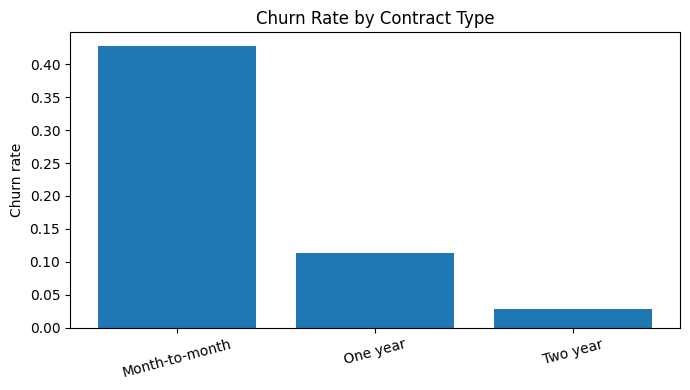

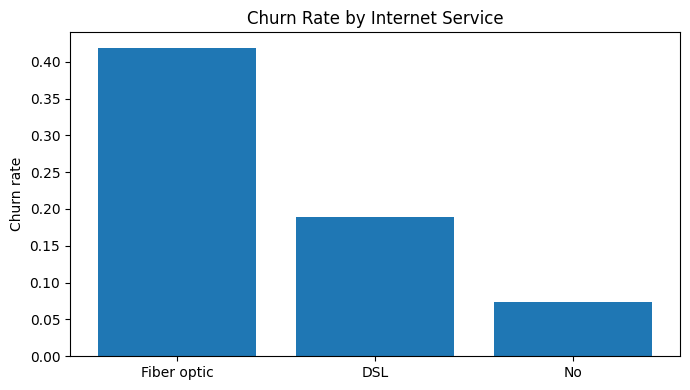

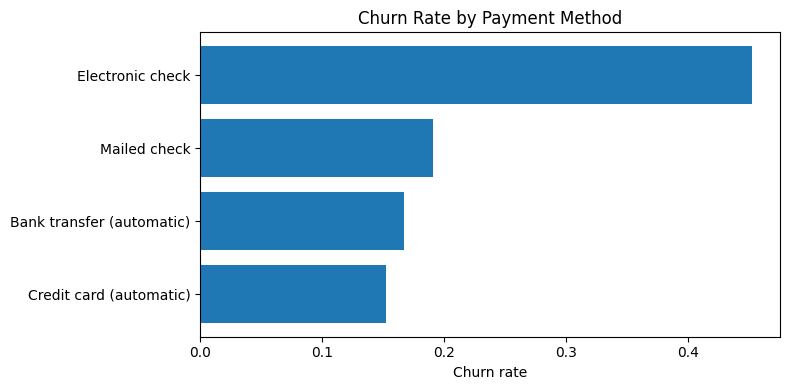

In [14]:
# Visualize churn rates for three interpretable categorical features.
contract_rates = churn_rate_table("Contract")["churn_rate"].sort_values(ascending=False)
plt.figure(figsize=(7, 4))
plt.bar(contract_rates.index, contract_rates.values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

internet_rates = churn_rate_table("InternetService")["churn_rate"].sort_values(ascending=False)
plt.figure(figsize=(7, 4))
plt.bar(internet_rates.index, internet_rates.values)
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

payment_rates = churn_rate_table("PaymentMethod")["churn_rate"].sort_values(ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(payment_rates.index, payment_rates.values)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn rate")
plt.tight_layout()
plt.show()

In [15]:
# Correlation is used only as an exploratory association measure.
# This separate encoding is for interpretation only; it is NOT used to train the model.
association_X = X.copy()
association_X["TotalCharges"] = association_X["TotalCharges"].fillna(
    association_X["TotalCharges"].median()
)
association_X = pd.get_dummies(association_X, drop_first=False, dtype=int)

correlation_data = pd.concat([association_X, y.rename("Churn")], axis=1)
churn_corr = (
    correlation_data.corr(numeric_only=True)["Churn"]
    .drop("Churn")
    .sort_values()
)

print("Features most negatively associated with churn:")
display(churn_corr.head(10).to_frame("correlation"))

print("Features most positively associated with churn:")
display(churn_corr.tail(10).sort_values(ascending=False).to_frame("correlation"))

Features most negatively associated with churn:


,correlation
tenure,-0.352
Contract_Two year,-0.302
StreamingTV_No internet service,-0.228
OnlineBackup_No internet service,-0.228
DeviceProtection_No internet service,-0.228
InternetService_No,-0.228
OnlineSecurity_No internet service,-0.228
TechSupport_No internet service,-0.228
StreamingMovies_No internet service,-0.228
TotalCharges,-0.199


Features most positively associated with churn:


,correlation
Contract_Month-to-month,0.405
OnlineSecurity_No,0.343
TechSupport_No,0.337
InternetService_Fiber optic,0.308
PaymentMethod_Electronic check,0.302
OnlineBackup_No,0.268
DeviceProtection_No,0.252
MonthlyCharges,0.193
PaperlessBilling_Yes,0.192
Dependents_No,0.164


In [16]:
# Majority-class baseline and comparison with the original k=5 model.
majority_baseline = max(y_test.mean(), 1 - y_test.mean())
selected_accuracy = accuracy_score(y_test, best_pred)

baseline_metrics = pd.DataFrame({
    "k=5 baseline": {
        "accuracy": accuracy_score(y_test, pred_5),
        "precision": precision_score(y_test, pred_5),
        "recall": recall_score(y_test, pred_5),
        "f1": f1_score(y_test, pred_5),
    },
    f"k={best_k} CV-selected": {
        "accuracy": selected_accuracy,
        "precision": precision_score(y_test, best_pred),
        "recall": recall_score(y_test, best_pred),
        "f1": f1_score(y_test, best_pred),
    },
}).T

print(f"Majority-class accuracy baseline: {majority_baseline:.3%}")
print("\nTest-set comparison:")
display(baseline_metrics)

# Exact confusion-matrix counts for interpretation.
tn, fp, fn, tp = best_cm.ravel()
print(f"True negatives:  {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives:  {tp}")

# Extra numeric context for the churn analysis.
numeric_churn_summary = (
    df.assign(ChurnFlag=df["Churn"].eq("Yes").astype(int))
      .groupby("Churn")[["tenure", "MonthlyCharges"]]
      .agg(["mean", "median"])
)
print("\nTenure and MonthlyCharges by churn group:")
display(numeric_churn_summary)

Majority-class accuracy baseline: 73.456%

Test-set comparison:


,accuracy,precision,recall,f1
k=5 baseline,0.764,0.553,0.575,0.564
k=15 CV-selected,0.777,0.583,0.564,0.573


True negatives:  884
False positives: 151
False negatives: 163
True positives:  211

Tenure and MonthlyCharges by churn group:


tenure        MonthlyCharges       
        mean median           mean median
Churn                                    
No    37.570 38.000         61.265 64.425
Yes   17.979 10.000         74.441 79.650

### Final findings

- Five-fold stratified cross-validation selects **`k = 15`** as the strongest of the required values by mean F1 score (about **0.578** across the training folds). The close scores for `k = 9`, `11`, and `15` also show that the exact optimum is not perfectly stable.
- On the untouched test set, the selected `k = 15` model reaches about **77.7% accuracy**, **58.3% precision**, **56.4% recall**, and **57.3% F1** for the churn class.
- Because only about 26.5% of customers churn, the majority-class baseline is already about **73.5% accuracy**, so accuracy must not be interpreted by itself.
- The confusion matrix contains **211 true positives**, **163 false negatives**, **151 false positives**, and **884 true negatives**. A recall of about 56% means the model still misses a substantial share of actual churners; improving recall may therefore be more valuable than maximizing accuracy for a retention campaign.
- The clearest exploratory churn patterns are associated with **month-to-month contracts**, **fiber-optic internet**, **electronic-check payments**, **shorter tenure**, lack of **online security/tech support**, and higher monthly charges. These are associations, not causal conclusions.

### Business recommendations

1. Prioritize retention outreach toward customers on month-to-month contracts, especially newer customers and customers using fiber-optic service.
2. Investigate why electronic-check users and customers without online security/technical support show higher churn rates; these groups may benefit from targeted onboarding or service bundles.
3. Use the model as a screening tool rather than an automatic decision system. Customers flagged as high risk can be passed to a retention workflow for further review.
4. For a real business deployment, choose the operating point based on the business cost of **false negatives** (missed churners) versus **false positives** (unnecessary retention actions), rather than accuracy alone.

### Limitations and future improvements

- The data is imbalanced, and the selected KNN model still misses many churners.
- KNN does not provide native feature-importance explanations, and the associations above are not causal conclusions.
- Cross-validation makes the `k` selection more robust than a single split, but performance should still be validated on fresh data over time.
- Future work should compare KNN with models such as Logistic Regression, Random Forest, or gradient boosting, and should evaluate ROC-AUC / Precision-Recall metrics and probability thresholds.
- Business costs should be included explicitly when choosing a prediction threshold or retention strategy.